# Week 5 Lecture Notes: Lindholm Chapter 4 - Understanding, Evaluating, and Improving Performance

## Contents

- [Scope for Week 5](#scope-for-week-5)
- [Learning goals for this notebook](#learning-goals-for-this-notebook)
- [Week 5 lecture summary (follow delivery order)](#week-5-lecture-summary-follow-delivery-order)
  - [1. Opening exam question: read the tree, then justify the path](#1-opening-exam-question-read-the-tree-then-justify-the-path)
  - [2. Why this week matters even if it feels theoretical](#2-why-this-week-matters-even-if-it-feels-theoretical)
  - [3. The real objective: expected new data error](#3-the-real-objective-expected-new-data-error)
  - [4. Assumptions behind the theory](#4-assumptions-behind-the-theory)
  - [5. Why training error is not enough](#5-why-training-error-is-not-enough)
  - [6. Estimating new-data performance in practice](#6-estimating-new-data-performance-in-practice)
  - [7. Model complexity and the generalisation gap](#7-model-complexity-and-the-generalisation-gap)
  - [8. Bias-variance decomposition as the main conceptual tool](#8-bias-variance-decomposition-as-the-main-conceptual-tool)
  - [9. Binary-classifier evaluation and the closing exam link](#9-binary-classifier-evaluation-and-the-closing-exam-link)
- [Chapter 4 summary](#chapter-4-summary)
  - [Performance in production: expected new data error](#performance-in-production-expected-new-data-error)
  - [Estimating Expected New Data Error](#estimating-expected-new-data-error)
    - [Why training error is optimistic](#why-training-error-is-optimistic)
    - [Hold-out validation](#hold-out-validation)
    - [k-fold cross-validation](#k-fold-cross-validation)
    - [Why we still need a final test set](#why-we-still-need-a-final-test-set)
  - [Training error, generalisation gap, and model complexity](#training-error-generalisation-gap-and-model-complexity)
  - [Bias-variance decomposition](#bias-variance-decomposition)
  - [Additional tools for evaluating binary classifiers](#additional-tools-for-evaluating-binary-classifiers)
    - [Confusion matrix](#confusion-matrix)
    - [Precision, recall, and F-scores](#precision-recall-and-f-scores)
    - [ROC and precision-recall curves](#roc-and-precision-recall-curves)
- [Exam-oriented takeaways](#exam-oriented-takeaways)
- [Past exam questions (2023-2025)](#past-exam-questions-2023-2025)
- [Toy example 1: training error vs hold-out vs 5-fold CV](#toy-example-1-training-error-vs-hold-out-vs-5-fold-cv)
- [Toy example 2: empirical bias-variance trade-off](#toy-example-2-empirical-bias-variance-trade-off)
- [Toy example 3: confusion matrix, ROC, and threshold trade-offs](#toy-example-3-confusion-matrix-roc-and-threshold-trade-offs)
- [Week 5 wrap-up](#week-5-wrap-up)
- [Sources used](#sources-used)

## Scope for Week 5

- Topic: performance.
- Important concepts: generalisation, model evaluation, model selection and complexity, overfitting and underfitting, bias-variance decomposition.
- Techniques: hold-out validation, `k`-fold cross-validation, confusion matrices, ROC curves.
- Reading: [Lindholm (2022), Chapter 4](../../references/main-text-book-machine-learning-lindholm-2022.pdf).
- Prac alignment: Week 5 practical covers performance; demos continue this week.
- Source note: these notes use the week 5 transcript, Lindholm Chapter 4, the local MATLAB lecture notes bundle in `references/lecture_notes_matlab_2026_v2.pdf`, and the indexed exam materials.

## Learning goals for this notebook

1. Explain what the course means by performance "in production" and why `E_train` is not the quantity we actually care about.
2. Distinguish hold-out validation, `k`-fold cross-validation, validation-based model selection, and the role of a final test set.
3. Connect underfitting, overfitting, generalisation gap, bias-variance, confusion matrices, and ROC-AUC to the style of questions that show up in COMP4702 exams.

## Week 5 lecture summary (follow delivery order)

### 1. Opening exam question: read the tree, then justify the path

- Marcus Gallagher opened with an Echo poll built from a 2025-style decision-tree exam question on the Iris dataset before moving into the new theory.
  - The immediate task was not "know this week's formulas first"; it was to read a trained tree, trace a test point from the root through the thresholds, and explain why the final leaf gives the prediction.
  - He explicitly pointed out that a few marks come from the explanation, not just the class label, so exam answers need the decision path in words.
  - This opening set up a theme for the whole lecture: evaluation questions in COMP4702 are often about interpreting model behaviour carefully, not just quoting definitions.

### 2. Why this week matters even if it feels theoretical

- Marcus Gallagher said Week 5 and Week 6 step back from introducing new model families so the course can build firmer foundations for judging whether a model is actually any good.
  - He called the topic a bit dry, but also said it is "really very, very important", especially because modern AI work is often evaluated too quickly and too loosely.
  - His framing was practical: if evaluation is weak, any downstream claim about model quality is weak too.
  - Exam-focused interpretation: when a question asks about validation, model choice, or overfitting, the marker is looking for this disciplined evaluation mindset rather than a memorised slogan.

### 3. The real objective: expected new data error

- Marcus Gallagher then reframed supervised learning around `E_new`, the expected new data error, as the quantity we actually want to make small.
  - He tied `E_new` directly to the plain-language idea of "performance in production": how the model behaves on data it has never seen before.
  - He distinguished the **error function** used for evaluation from the **loss function** used for training, stressing that they can differ even though they should still be related.
  - The concrete examples he gave were squared error for regression and misclassification error for classification.
  - The textbook equations matter here, but his spoken emphasis was conceptual: low training loss is not the same statement as good generalisation.

### 4. Assumptions behind the theory

- Marcus Gallagher justified the `E_new` setup by introducing the default probabilistic assumptions sitting behind most of the course material.
  - Data are imagined as coming from an underlying distribution `p(x, y)` that we do not know directly.
  - He said the analysis assumes that distribution is **stationary**, so data collected at different times are still governed by the same process.
  - He also assumed the data are drawn **IID**: independent and identically distributed, with no special meaning attached to the order in which points appear.
  - His explicit counterexample was time-series prediction, where non-stationarity and dependence usually break these assumptions.
  - Inference from supporting material: this is the background that makes hold-out validation and cross-validation sensible in the first place.

### 5. Why training error is not enough

- After defining `E_train`, Marcus Gallagher paused on the book's deliberately strong claim that training error "gives no information" about performance on unseen data.
  - He said it sounds weird at first, then defended it with the lookup-table example: a model can memorise the training set and score perfectly on `E_train` while being useless as a predictor.
  - The message was conservative rather than absolute: training performance can be encouraging, but it is not an honest estimate of future performance by itself.
  - This is the core Week 5 correction to the instinct that "small training error means the model is good."

### 6. Estimating new-data performance in practice

- Marcus Gallagher moved from the theoretical `E_new` definition to the practical question of how to estimate it well enough to compare models and choose hyperparameters.
  - He linked this directly to **model selection** and **model configuration**: choosing a model family such as a decision tree versus logistic regression, and then choosing settings such as tree depth or `k` in `k`-NN.
  - He also framed performance estimation as a stakeholder question: if someone pays for a model, they reasonably want a defensible estimate of how well it will perform after deployment.
  - Inference cross-checked against the rest of the notebook and Chapter 4: this is the point in the lecture where hold-out validation, `k`-fold cross-validation, and the role of a final untouched test set fit into the story.

### 7. Model complexity and the generalisation gap

- Marcus Gallagher used the textbook figures to connect model complexity with the gap between training performance and new-data performance.
  - His running point was that increasing complexity often lowers training error while widening the generalisation gap.
  - He walked through examples where the complexity control differs by model family: tree depth for regression trees and regularisation strength for linear-style models.
  - He answered a class question by saying this picture is mainly conceptual at this stage; the goal is to understand the phenomenon before turning it into concrete procedures.
  - Exam-focused interpretation: for COMP4702, "underfitting" and "overfitting" answers should describe the joint behaviour of training fit, generalisation gap, and model complexity rather than treating them as isolated buzzwords.

### 8. Bias-variance decomposition as the main conceptual tool

- Marcus Gallagher presented bias-variance decomposition as the most useful theoretical lens for explaining why the complexity picture behaves the way it does.
  - He first backed out to a statistics example using noisy GPS location measurements to separate **bias** (systematic offset from the truth) from **variance** (sampling-driven variability across repeated measurements).
  - He then mapped that idea back to machine learning: the learned predictor changes when the training set changes, and expected squared error can be decomposed into squared bias, variance, and irreducible error.
  - His explicit instruction was not to memorise a derivation, but to understand what each term means and how the terms move as model complexity changes.
  - He also highlighted [Lindholm (2022), Example 4.3 and Example 4.4](../../references/main-text-book-machine-learning-lindholm-2022.pdf) as the textbook examples worth reading carefully this week because they make the trade-off concrete.

### 9. Binary-classifier evaluation and the closing exam link

- Marcus Gallagher used the last part of the lecture to introduce evaluation tools that are more informative than a single error rate, especially for binary classifiers.
  - He defined the confusion matrix through the four outcomes `TN`, `FN`, `FP`, and `TP`, and stressed that it reveals which kind of error the classifier is making.
  - He flagged `F1` as a common metric when classes are imbalanced or when one type of mistake matters more than the other.
  - He also mentioned ROC curves, but said he would spend a few minutes on them next week instead of pushing too much into the final minutes of this lecture.
  - The lecture closed by returning to the opening exam figure and asking the class to think about the confusion matrix implied by that decision tree, which neatly linked the theory back to the exam style from the first five minutes.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 4702
random.seed(SEED)
np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 120

print(f"Seed set to {SEED}")

Seed set to 4702


## Chapter 4 summary

Chapter 4 is about **how to judge whether a machine-learning model is actually useful**. The key shift is from asking

- "How well does the model fit the training data?"

to asking

- "How well will it perform on new, unseen data?"

That shift is the backbone of Week 5.

### Performance in production: expected new data error

Lindholm starts by separating the **error function** used for evaluating a trained model from the **loss function** used to train a model.

Default error functions:

$$
E(\hat{y}, y) = I\{\hat{y} \neq y\} \qquad \text{(classification)} \tag{4.1a}
$$

$$
E(\hat{y}, y) = (\hat{y} - y)^2 \qquad \text{(regression)} \tag{4.1b}
$$

Important distinction:

- a **loss** drives optimisation during training,
- an **error function** measures performance after training,
- the two do not have to be the same.

The central quantity in Chapter 4 is the **expected new data error**:

$$
E_{\text{new}} = \mathbb{E}_\star\left[E\bigl(\hat{y}(x_\star; T), y_\star\bigr)\right]. \tag{4.2}
$$

This is the expected error on future data points drawn from the same underlying data distribution. It is the mathematical version of "performance in production."

The training error is

$$
E_{\text{train}} = \frac{1}{n} \sum_{i=1}^{n} E\bigl(\hat{y}(x_i; T), y_i\bigr). \tag{4.4}
$$

This is easier to compute, but it is not what we ultimately want.

One-sentence summary:

- **Objective**: achieve low error on unseen data, not just low error on the data already used for training.

Why this matters:

- a model can fit training data very well and still fail on new data,
- model selection, hyperparameter tuning, and evaluation all exist because `E_new` is what counts.

### Estimating Expected New Data Error

We cannot compute `E_new` exactly in real problems because the true data distribution is unknown. Chapter 4 therefore focuses on **estimating** it.

#### Why training error is optimistic

It is tempting to treat `E_train` as an estimate of `E_new`, but Lindholm shows why this is wrong:

- the model already used the training data during learning,
- evaluating on the same data double-counts that information,
- therefore `E_train` is typically too optimistic.

The usual relationship is:

$$
E_{\text{train}} < E_{\text{new}}.
$$

This is the practical reason you should be suspicious of any model that looks perfect on training data.

#### Hold-out validation

The simplest fix is to set aside validation data that is **not** used for training:

$$
E_{\text{hold-out}} = \frac{1}{n_v} \sum_{j=1}^{n_v} E\bigl(\hat{y}(x'_j; T), y'_j\bigr). \tag{4.6}
$$

Core idea:

- train on one subset,
- evaluate on a separate subset,
- now the evaluation data was not used to fit the model.

Important Week 5 points:

- split randomly after shuffling,
- if the dataset is sorted and you split naively, the validation set can become unrepresentative,
- a larger hold-out set gives a lower-variance estimate of performance,
- but a larger hold-out set also leaves less data for training.

So hold-out validation creates a trade-off:

- better estimate of `E_new`,
- but potentially worse trained model because less data remains for fitting.

#### k-fold cross-validation

When data is limited, Chapter 4 recommends `k`-fold cross-validation.

Procedure:

1. split the data into `k` similarly sized batches,
2. choose one batch as validation and train on the other `k-1`,
3. repeat until each batch has served once as validation,
4. average the `k` validation errors,
5. then train the final model on all available data.

The cross-validation estimate is

$$
E_{k\text{-fold}} = \frac{1}{k}\sum_{\ell=1}^{k} E_{\text{hold-out}}^{(\ell)}. \tag{4.7}
$$

Why it helps:

- each intermediate model is trained on almost all of the data,
- averaging the `k` validation estimates reduces variance,
- the final model still gets to use the entire dataset.

Practical trade-off:

- larger `k` means intermediate models are closer to the final model,
- but computational cost rises because training is repeated more times,
- leave-one-out cross-validation (`k=n`) is the extreme case.

#### Why we still need a final test set

Chapter 4 makes a crucial point: once you use hold-out or cross-validation to select

- a model class,
- a polynomial degree,
- a tree depth,
- a regularisation strength,
- or any other hyperparameter,

you are now adapting to the validation data as well.

So if you want an honest final estimate of performance, you should set aside a **test set** and use it only once at the end.

The clean workflow is:

1. split off a final test set,
2. use the remaining data for training plus validation / cross-validation,
3. choose the model and hyperparameters,
4. retrain on all non-test data,
5. evaluate once on the test set.

This is exactly the split logic examined in [2024 exam PDF](../../references/2024_COMP4702_exam.pdf) Part A Question 4.

### Training error, generalisation gap, and model complexity

Lindholm next introduces training-data-averaged quantities:

$$
\bar{E}_{\text{new}} = \mathbb{E}_T[E_{\text{new}}(T)], \qquad \bar{E}_{\text{train}} = \mathbb{E}_T[E_{\text{train}}(T)]. \tag{4.8}
$$

This allows the decomposition

$$
\bar{E}_{\text{new}} = \bar{E}_{\text{train}} + \text{generalisation gap}. \tag{4.11}
$$

where

$$
\text{generalisation gap} = \bar{E}_{\text{new}} - \bar{E}_{\text{train}}. \tag{4.10}
$$

Interpretation:

- `\bar{E}_{train}` measures how well the model class fits the data it sees,
- the generalisation gap measures how much performance degrades when moving to unseen data.

This is where the standard underfitting/overfitting picture comes from.

Typical behaviour:

- increasing model complexity lowers training error,
- but usually enlarges the generalisation gap,
- so new-data error has a U-shape,
- too little complexity gives **underfitting**,
- too much complexity gives **overfitting**,
- some intermediate setting gives the best balance.

Chapter 4 also highlights the effect of more training data:

- more data usually shrinks the generalisation gap,
- complex models benefit from extra data more than simple models do,
- collecting better or more representative data can be as important as changing the model.

This gives a useful Week 5 diagnostic:

- if `E_train` is already high, the model may be too rigid or badly specified,
- if `E_train` is very low but validation error is much worse, the model is likely too flexible.

### Bias-variance decomposition

For regression with squared error, Lindholm gives the bias-variance decomposition. Assume

$$
y = f_0(x) + \epsilon, \qquad \mathbb{E}[\epsilon] = 0, \qquad \operatorname{var}(\epsilon) = \sigma^2. \tag{4.14}
$$

Define the average trained model

$$
\bar{f}(x) = \mathbb{E}_T[\hat{y}(x; T)]. \tag{4.15}
$$

Then the expected new-data error decomposes as

$$
\bar{E}_{\text{new}} =
\underbrace{\mathbb{E}_\star\bigl[(\bar{f}(x_\star) - f_0(x_\star))^2\bigr]}_{\text{Bias}^2}
+
\underbrace{\mathbb{E}_\star\Bigl[\mathbb{E}_T\bigl[(\hat{y}(x_\star; T) - \bar{f}(x_\star))^2\bigr]\Bigr]}_{\text{Variance}}
+
\underbrace{\sigma^2}_{\text{Irreducible error}}. \tag{4.19}
$$

Meaning:

- **Bias**: how far the average learned model is from the true underlying function,
- **Variance**: how much the learned model changes from one training dataset to another,
- **Irreducible error**: noise in the data that no model can remove.

This reframes model complexity more concretely:

- low-complexity models tend to have **high bias, low variance**,
- high-complexity models tend to have **low bias, high variance**.

That is the **bias-variance trade-off**.

The local week-05 figure asset is a good visual summary of this trade-off:

![Polynomial fits and bias-variance curves used in 2024 Part B Question 2](figures/exam-2024-fig-2-B-Q2.png)

Reading it correctly:

- order 1 polynomial: high bias, low variance,
- order 5 polynomial: low bias, high variance,
- order 3 polynomial: best balance in that example.

This section matters because exam questions often ask for:

- how more complex models can reduce bias but increase variance,
- why adding data often reduces variance,
- why the best model is usually not the one with the smallest training error.

### Additional tools for evaluating binary classifiers

Misclassification rate is a useful start, but Chapter 4 adds more precise tools, especially for imbalanced or asymmetric classification problems.

#### Confusion matrix

For binary classification, evaluating on a validation set gives four counts:

| Predicted / Actual | Negative (`y=-1`) | Positive (`y=1`) |
| --- | --- | --- |
| Predict negative | True negative (TN) | False negative (FN) |
| Predict positive | False positive (FP) | True positive (TP) |

Why it matters:

- it separates the two kinds of mistakes,
- false positives and false negatives are often not equally costly,
- raw accuracy hides that difference.

#### Precision, recall, and F-scores

Two especially important rates are:

$$
\text{recall} = \frac{TP}{P} = \frac{TP}{TP + FN}
$$

$$
\text{precision} = \frac{TP}{P^\*} = \frac{TP}{TP + FP}
$$

Interpretation:

- high **recall** means the classifier misses few positives,
- high **precision** means positive predictions are usually correct.

The `F_1` score combines them:

$$
F_1 = \frac{2 \cdot \text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}. \tag{4.24}
$$

When recall should count more than precision, use the more general `F_\beta` score:

$$
F_\beta = \frac{(1+\beta^2)\cdot \text{precision} \cdot \text{recall}}{\beta^2 \cdot \text{precision} + \text{recall}}. \tag{4.25}
$$

Use cases:

- `F_1` is often better than accuracy for imbalanced problems,
- `F_\beta` is useful for asymmetric problems where one type of miss matters more.

#### ROC and precision-recall curves

If a classifier produces scores or probabilities, many thresholds are possible.
Instead of committing to one threshold, Chapter 4 considers entire curves.

**ROC curve**

- horizontal axis: false positive rate,
- vertical axis: true positive rate (recall),
- each point corresponds to a different threshold.

Interpretation:

- top-left is good,
- diagonal is random guessing,
- area under the curve (**ROC-AUC**) summarises threshold-free ranking performance.

**Precision-recall curve**

- horizontal axis: recall,
- vertical axis: precision.

This is often more informative than ROC for severely imbalanced problems.

Week 5 exam link:

- [2025 exam PDF](../../references/2025_COMP4702_exam.pdf) Part A Question 5 tests ROC-AUC directly,
- confusion-matrix reasoning also reappears in tree and classifier interpretation questions.

## Exam-oriented takeaways

Most likely Week 5 ideas to be assessed:

1. explain the difference between `E_train`, `E_hold-out`, `E_{k-fold}`, and `E_new`,
2. explain why training error is not a reliable estimate of generalisation error,
3. perform simple split arithmetic for train/validation/test and cross-validation,
4. define overfitting, underfitting, model complexity, and generalisation gap,
5. explain the bias-variance trade-off,
6. identify what is and is not a hyperparameter,
7. interpret confusion matrices, recall, precision, `F_1`, and ROC-AUC.

Fast revision checklist:

- Can I state the purpose of a hold-out set in one sentence?
- Can I explain why validation data is not the same as a final test set?
- Can I say what happens to training error and generalisation gap as model complexity grows?
- Can I explain bias and variance separately, not as one vague idea?
- Can I distinguish accuracy, recall, precision, and ROC-AUC?

## Past exam questions (2023-2025)

These were selected using [exam_questions_2023_2025_by_week.csv](../../references/exam_questions_2023_2025_by_week.csv) and copied from [COMP4702_exams_2023_2025.md](../../references/COMP4702_exams_2023_2025.md).

### 2023 Part A, Question 3

Source: [2023 exam PDF](../../references/2023_COMP4702_exam.pdf)

- What is the purpose of a hold-out data set in machine learning?
- (a) To train the model on new data that it hasn’t seen before.
- (b) To estimate the accuracy of the model on data that it has not been trained on.
- (c) To fine-tune the model’s hyperparameters and avoid overfitting.
- (d) To estimate the accuracy of the model on data that it has already been trained on.

Revision note: the answer is **(b)**. The hold-out set is for estimating performance on unseen data, not for training.

### 2024 Part A, Question 4

Source: [2024 exam PDF](../../references/2024_COMP4702_exam.pdf)

- You are given 1000 data points to build a classifier. You shuffle the points randomly and then decide to put 10% of the data aside as a (final) test set and 20% of the data aside as a “validation” set, which you use to perform model selection and configuration (e.g. hyperparameter tuning). You then use 5-fold cross-validation training with the remaining data. How many data points are in each fold?
- (a) 100.
- (b) 700.
- (c) 300.
- (d) 140.

Revision note: the answer is **(d) 140** because `1000 -> 100` test, `200` validation, `700` remaining, then `700 / 5 = 140`.

### 2025 Part A, Question 4

Source: [2025 exam PDF](../../references/2025_COMP4702_exam.pdf)

- Which of the following is not an example of a hyperparameter?
- (a) The value of `k` in k-nearest neighbours.
- (b) The number of layers in a feed-forward neural network.
- (c) The offset term in linear regression, `\theta_0`.
- (d) The filter size in a convolutional neural network layer.

Revision note: the answer is **(c)** because `\theta_0` is a learned parameter, not a user-chosen hyperparameter.

### 2025 Part A, Question 5

Source: [2025 exam PDF](../../references/2025_COMP4702_exam.pdf)

- Which of the following is a commonly-used measure of the performance of a binary classifier:
- (a) The exponential loss function.
- (b) Area under the ROC curve.
- (c) The magnitude of the gradient with respect to the model parameters after training.
- (d) The F1 score divided by the mean-squared error.

Revision note: the answer is **(b)**. ROC-AUC is a standard threshold-independent evaluation measure for binary classification.

### 2023 Part B, Question 3

Source: [2023 exam PDF](../../references/2023_COMP4702_exam.pdf)

- Figure 3 is taken from the course textbook:
- (a) Explain how Figure 3 illustrates a fundamental tradeoff in machine learning. (5 marks)
- (b) If more data becomes available for training, what would be the typical effect on the `Bias^2` and `Variance` curves in Figure 3? (3 marks)

Revision note: this is a direct bias-variance question. The expected explanation is that increasing model complexity lowers bias and raises variance, while more training data usually reduces variance.

### 2024 Part B, Question 2

Source: [2024 exam PDF](../../references/2024_COMP4702_exam.pdf)

- Figure 2 shows two related Figures from a machine learning textbook:
- (a) The caption on Fig.4.6 states that the plot was produced using 100 models (each based on a sample of twenty instances as mentioned in the caption for Fig.4.5). Explain exactly how each of the curves could have been calculated using the 100 models and sample data sets. (4 marks)
- (b) Explain the general relationship between underfitting, overfitting and model complexity in supervised learning. You should refer to Figure 2 to assist with your explanation. (6 marks)

Revision note: this tests whether you can explain both the picture and the process behind it, not just say "U-shaped curve" mechanically.

### 2025 Part B, Question 5

Source: [2025 exam PDF](../../references/2025_COMP4702_exam.pdf)

- Figure 4 (a,b,c) shows different polynomial regression models trained on a 1-D dataset. The Mean Squared Error versus the degree of polynomial for a range of models is also shown (d).
- (a) Use Figure 4 to make an argument as to why the training set error does NOT provide a good estimate of the generalisation error of a machine learning model? (4 marks)
- (b) Use Figure 4 to give a short explanation for the phenomena of underfitting, overfitting and model complexity in machine learning. (4 marks)

Revision note: this is the Week 5 idea in its most exam-direct form. Be able to answer it without needing the exact figure in front of you.

## Toy example 1: training error vs hold-out vs 5-fold CV

This example uses polynomial regression on noisy data to show why training error is optimistic and why validation-style estimates are more useful for model selection.

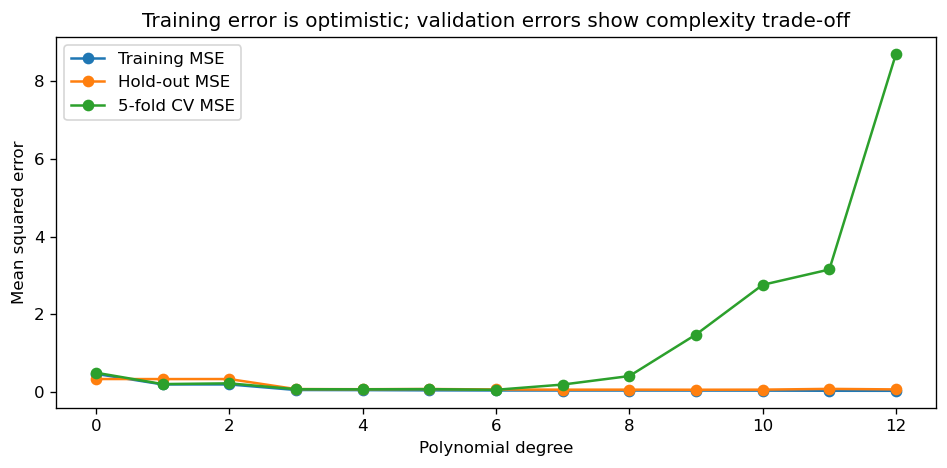

Best degree by training error: 12
Best degree by hold-out error: 9
Best degree by 5-fold CV error: 6


In [2]:
def poly_design(x, degree):
    return np.column_stack([x**d for d in range(degree + 1)])


def fit_least_squares(x, y, degree):
    X = poly_design(x, degree)
    theta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return theta


def predict_poly(x, theta):
    degree = len(theta) - 1
    return poly_design(x, degree) @ theta


def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


rng = np.random.default_rng(SEED)
x_all = rng.uniform(-1.0, 1.0, 60)
y_all = np.sin(np.pi * x_all) + 0.25 * rng.normal(size=x_all.size)

perm = rng.permutation(len(x_all))
train_idx = perm[:45]
hold_idx = perm[45:]

x_train, y_train = x_all[train_idx], y_all[train_idx]
x_hold, y_hold = x_all[hold_idx], y_all[hold_idx]

degrees = np.arange(0, 13)
train_errors = []
hold_errors = []
cv_errors = []

cv_perm = rng.permutation(len(x_train))
folds = np.array_split(cv_perm, 5)

for degree in degrees:
    theta = fit_least_squares(x_train, y_train, degree)
    train_errors.append(mse(y_train, predict_poly(x_train, theta)))
    hold_errors.append(mse(y_hold, predict_poly(x_hold, theta)))

    fold_mses = []
    for fold in folds:
        fold_train_mask = np.ones(len(x_train), dtype=bool)
        fold_train_mask[fold] = False
        x_tr = x_train[fold_train_mask]
        y_tr = y_train[fold_train_mask]
        x_va = x_train[fold]
        y_va = y_train[fold]

        theta_cv = fit_least_squares(x_tr, y_tr, degree)
        fold_mses.append(mse(y_va, predict_poly(x_va, theta_cv)))

    cv_errors.append(np.mean(fold_mses))

train_errors = np.array(train_errors)
hold_errors = np.array(hold_errors)
cv_errors = np.array(cv_errors)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(degrees, train_errors, "o-", label="Training MSE")
ax.plot(degrees, hold_errors, "o-", label="Hold-out MSE")
ax.plot(degrees, cv_errors, "o-", label="5-fold CV MSE")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("Mean squared error")
ax.set_title("Training error is optimistic; validation errors show complexity trade-off")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best degree by training error: {degrees[np.argmin(train_errors)]}")
print(f"Best degree by hold-out error: {degrees[np.argmin(hold_errors)]}")
print(f"Best degree by 5-fold CV error: {degrees[np.argmin(cv_errors)]}")

What to check:

- training error usually keeps dropping as degree increases,
- hold-out and CV error typically fall then rise,
- the best generalising degree is usually not the one with the lowest training error.

## Toy example 2: empirical bias-variance trade-off

This example follows the style of the Chapter 4 polynomial-fit figures: fit multiple models to multiple noisy datasets and measure the average bias and variance.

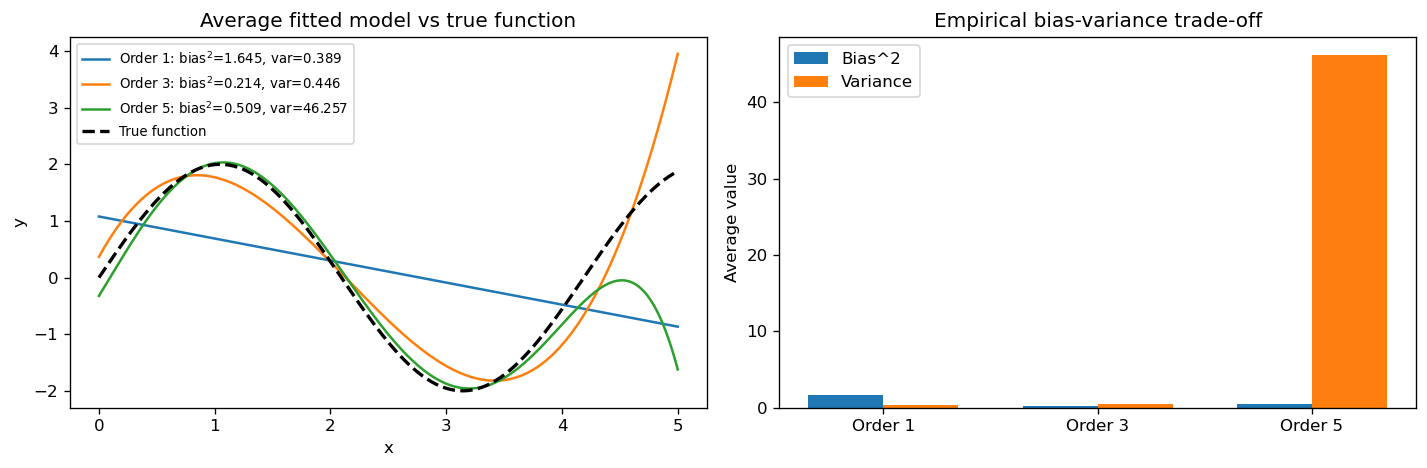

Degree  Bias^2   Variance
     1   1.645      0.389
     3   0.214      0.446
     5   0.509     46.257


In [3]:
def true_function(x):
    return 2.0 * np.sin(1.5 * x)


def empirical_bias_variance(degree, n_repeats=100, n_points=20):
    x_grid = np.linspace(0.0, 5.0, 250)
    preds = []

    for _ in range(n_repeats):
        x = np.sort(rng.uniform(0.0, 5.0, n_points))
        y = true_function(x) + rng.normal(0.0, 1.0, size=n_points)
        theta = fit_least_squares(x, y, degree)
        preds.append(predict_poly(x_grid, theta))

    preds = np.array(preds)
    mean_pred = preds.mean(axis=0)
    bias2 = np.mean((mean_pred - true_function(x_grid)) ** 2)
    variance = np.mean((preds - mean_pred) ** 2)
    return x_grid, mean_pred, preds, bias2, variance


degrees_to_compare = [1, 3, 5]
stats = {}
rng = np.random.default_rng(SEED)

for degree in degrees_to_compare:
    stats[degree] = empirical_bias_variance(degree)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for degree in degrees_to_compare:
    x_grid, mean_pred, preds, bias2, variance = stats[degree]
    ax.plot(x_grid, mean_pred, label=fr"Order {degree}: bias$^2$={bias2:.3f}, var={variance:.3f}")
ax.plot(x_grid, true_function(x_grid), "k--", linewidth=2, label="True function")
ax.set_title("Average fitted model vs true function")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=8)

ax = axes[1]
bias2_values = [stats[d][3] for d in degrees_to_compare]
variance_values = [stats[d][4] for d in degrees_to_compare]
xpos = np.arange(len(degrees_to_compare))
width = 0.35
ax.bar(xpos - width / 2, bias2_values, width, label="Bias^2")
ax.bar(xpos + width / 2, variance_values, width, label="Variance")
ax.set_xticks(xpos)
ax.set_xticklabels([f"Order {d}" for d in degrees_to_compare])
ax.set_ylabel("Average value")
ax.set_title("Empirical bias-variance trade-off")
ax.legend()

plt.tight_layout()
plt.show()

print("Degree  Bias^2   Variance")
for degree in degrees_to_compare:
    print(f"{degree:>6}  {stats[degree][3]:>6.3f}   {stats[degree][4]:>8.3f}")

Expected pattern:

- lower-order polynomials have higher bias and lower variance,
- higher-order polynomials reduce bias but increase variance,
- the best complexity is the one with the best balance, not the most flexible model.

## Toy example 3: confusion matrix, ROC, and threshold trade-offs

This example simulates an imbalanced binary-classification problem and compares two thresholds.

Threshold = 0.50
  TN=205, FP=9, FN=1, TP=35
  accuracy=0.960, precision=0.795, recall=0.972, F1=0.875, FPR=0.042
Threshold = 0.25
  TN=129, FP=85, FN=0, TP=36
  accuracy=0.660, precision=0.298, recall=1.000, F1=0.459, FPR=0.397


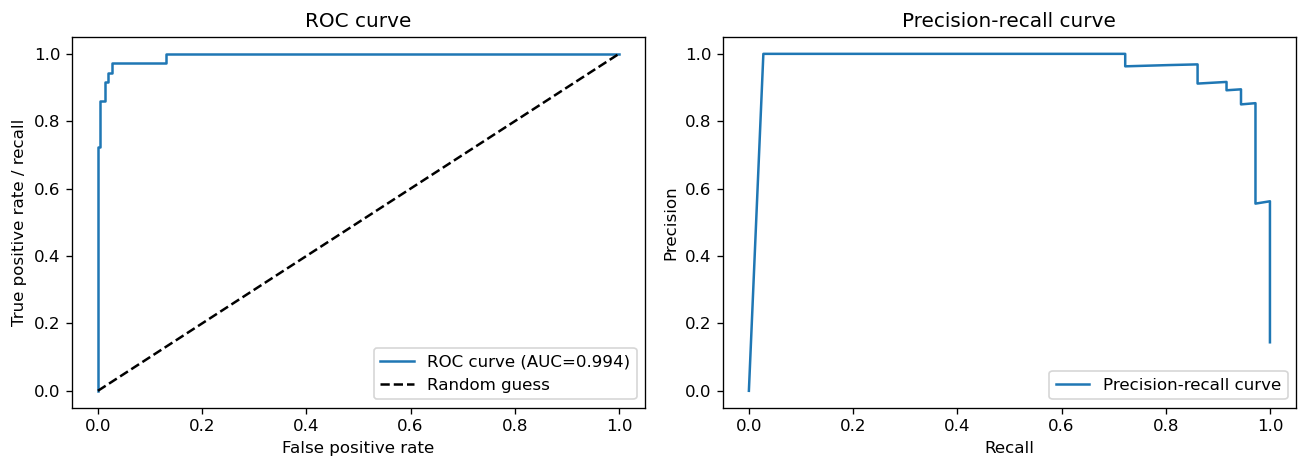

In [4]:
def confusion_counts(y_true, y_pred):
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    return tn, fp, fn, tp


def metrics_from_counts(tn, fp, fn, tp):
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    return precision, recall, fpr, f1, accuracy


def roc_pr_points(y_true, scores):
    thresholds = np.r_[1.01, np.sort(np.unique(scores))[::-1], -0.01]
    roc = []
    pr = []
    for thr in thresholds:
        y_pred = (scores >= thr).astype(int)
        tn, fp, fn, tp = confusion_counts(y_true, y_pred)
        precision, recall, fpr, _, _ = metrics_from_counts(tn, fp, fn, tp)
        roc.append((fpr, recall))
        pr.append((recall, precision))
    roc = np.array(roc)
    pr = np.array(pr)
    roc_auc = np.trapezoid(roc[:, 1], roc[:, 0])
    return roc, pr, roc_auc


rng = np.random.default_rng(SEED)
n = 250
y_true = rng.choice([0, 1], size=n, p=[0.85, 0.15])

# Synthetic scores with partial separation between the classes
scores = np.clip(0.18 + 0.55 * y_true + 0.18 * rng.normal(size=n), 0.0, 1.0)

thresholds_to_compare = [0.50, 0.25]

for threshold in thresholds_to_compare:
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    precision, recall, fpr, f1, accuracy = metrics_from_counts(tn, fp, fn, tp)
    print(f"Threshold = {threshold:.2f}")
    print(f"  TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"  accuracy={accuracy:.3f}, precision={precision:.3f}, recall={recall:.3f}, F1={f1:.3f}, FPR={fpr:.3f}")

roc, pr, roc_auc = roc_pr_points(y_true, scores)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(roc[:, 0], roc[:, 1], label=f"ROC curve (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Random guess")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate / recall")
ax.set_title("ROC curve")
ax.legend()

ax = axes[1]
ax.plot(pr[:, 0], pr[:, 1], label="Precision-recall curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall curve")
ax.legend()

plt.tight_layout()
plt.show()

Interpretation:

- lowering the threshold usually increases recall,
- but often at the cost of more false positives and lower precision,
- ROC-AUC summarises ranking performance over all thresholds rather than one chosen cutoff.

## Week 5 wrap-up

What to remember:

1. `E_new` is the real target; `E_train` is only what the model does on data it already saw.
2. Training error is usually optimistic and cannot stand in for generalisation error.
3. Hold-out validation and `k`-fold cross-validation are tools for estimating performance on unseen data.
4. Validation data is for model selection; a final test set is for one honest final estimate.
5. Overfitting and underfitting are best understood through the interaction of training error and generalisation gap.
6. Bias-variance explains *why* model complexity creates that trade-off.
7. Confusion matrices, precision, recall, `F_1`, and ROC-AUC are core tools for classifier evaluation.

What connects forward:

- Week 6 uses these evaluation ideas to justify regularisation, early stopping, and hyperparameter tuning.
- Later topics reuse the same Week 5 logic whenever model complexity or class imbalance becomes important.

## Sources used

1. [Course Summary Table, Semester 1 2026](../../references/CourseSummaryTable_v1_26.pdf)
2. [Lindholm, Chapter 4](../../references/main-text-book-machine-learning-lindholm-2022.pdf)
3. [Indexed exam questions by week](../../references/exam_questions_2023_2025_by_week.csv)
4. [Extracted exam text 2023-2025](../../references/COMP4702_exams_2023_2025.md)
5. [Week 5 figure crop reused from 2024 Part B Question 2](figures/exam-2024-fig-2-B-Q2.png)

Local-source note: `references/lecture_notes_matlab_2026_v1.pdf` was not present in this repo, so it was not used.